In [1]:
from configs import paths
import pandas as pd
import numpy as np
import os

In [2]:
path = os.path.join(paths.CONFIG["paths"]["gt"], "gt_20006-1.csv")
path_model = os.path.join(paths.CONFIG["paths"]["ready"], "20006-1.csv")
gt = pd.read_csv(path)
df = pd.read_csv(path_model)
df = df[["part_id", "x", "y","z"]]
df.head()

,part_id,x,y,z
0,0,0.0,0.0,0.0
1,1,20.0,0.0,0.0
2,2,10.0,24.0,-120.0
3,3,10.0,24.0,120.0
4,4,10.0,0.0,130.0


In [3]:
gt = gt.merge(
    df.rename(columns={
        "part_id": "part_id_1",
        "x": "x_1",
        "y": "y_1",
        "z": "z_1"
    }),
    on="part_id_1",
    how="left"
)


gt = gt.merge(
    df.rename(columns={
        "part_id": "part_id_2",
        "x": "x_2",
        "y": "y_2",
        "z": "z_2"
    }),
    on="part_id_2",
    how="left"
)


gt["dx"] = gt["x_1"] - gt["x_2"]
gt["dy"] = gt["y_1"] - gt["y_2"]
gt["dz"] = gt["z_1"] - gt["z_2"]
gt["r"] = np.sqrt(gt["dx"]**2+
                  gt["dy"]**2+
                  gt["dz"]**2
                  )
gt = gt[["part_id_1", "part_id_2", "dx", "dy", "dz","r", "connected"]]
gt["r2"] = gt["r"]**2
gt.head()


,part_id_1,part_id_2,dx,dy,dz,r,connected,r2
0,0,1,-20.0,0.0,0.0,20.000000,0,400.0
1,0,2,-10.0,-24.0,120.0,122.784364,1,15076.0
2,0,3,-10.0,-24.0,-120.0,122.784364,1,15076.0
3,0,4,-10.0,0.0,-130.0,130.384048,0,17000.0
4,0,5,-10.0,0.0,130.0,130.384048,0,17000.0


Logistische Regression:

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve

In [5]:
X = gt[["dx", "dy", "dz"]]
X2 = gt[["r","r2"]]
y = gt["connected"]

In [6]:
X.describe()

,dx,dy,dz
count,2278.000000,2278.000000,2278.000000
mean,3.144864,-3.975417,4.341528
std,32.773468,45.501271,107.509357
min,-96.000000,-122.000000,-280.000000
25%,-20.000000,-36.000000,-70.000000
50%,0.000000,0.000000,0.000000
75%,20.000000,32.000000,80.000000
max,104.000000,112.000000,280.000000


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [8]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced"))
])
pipe.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [9]:
y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.98      0.49      0.65       551
           1       0.05      0.74      0.09        19

    accuracy                           0.49       570
   macro avg       0.51      0.61      0.37       570
weighted avg       0.95      0.49      0.63       570

ROC-AUC: 0.5452765307097144


In [10]:
y.value_counts(normalize=True)

connected
0    0.966637
1    0.033363
Name: proportion, dtype: float64

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X2, y, test_size=0.25, random_state=42, stratify=y
)
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced"))
])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.99      0.80      0.88       551
           1       0.12      0.79      0.21        19

    accuracy                           0.80       570
   macro avg       0.55      0.79      0.54       570
weighted avg       0.96      0.80      0.86       570

ROC-AUC: 0.8510841532142516


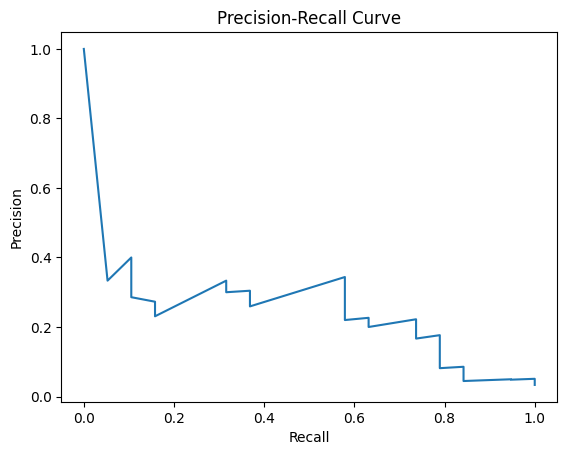

In [14]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
import matplotlib.pyplot as plt
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()